# Jaguar Re-ID — ResNet-34 Improved v7

**Architecture** : ResNet-34 (BatchNorm + ReLU, Dropout 0.4, AdamW)  
**Changement vs 06_6** : Sweep sur label smoothing (α = 0.05, 0.1, 0.15, 0.2)  
**LR fixé** : 1e-3 (meilleur LR confirmé dans 06_6)

## 1. Setup & data loading

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.data import load_data, load_test_pairs, get_augmentation

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1776169973.066291   73657 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776169973.108301   73657 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776169973.894525   73657 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1776169974.579100   73657 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [2]:
PROJECT_ROOT   = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR       = os.path.join(PROJECT_ROOT, 'data')
CLEANED_DIR    = os.path.join(DATA_DIR, 'cleaned')
OUTPUT_DIR     = os.path.join(PROJECT_ROOT, 'outputs')
SUBMISSION_DIR = os.path.join(PROJECT_ROOT, 'submissions')
LOG_DIR        = os.path.join(PROJECT_ROOT, 'tensorboards')

IMG_SIZE = 224
NUM_CLASSES = 31
BATCH_SIZE = 64
SEED = 42

MODEL_NAME   = 'resnet34_improved_v7'
AUGMENTATION = 'none'
LR           = 1e-3       # Fixé (meilleur LR de 06_6)
WEIGHT_DECAY = 5e-4

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

In [3]:
X_train, y_train = load_data('train')
X_val, y_val     = load_data('val')
X_test, test_filenames = load_data('test')
test_pairs_df = load_test_pairs()

# One-hot encoding for label smoothing
y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh   = tf.keras.utils.to_categorical(y_val, NUM_CLASSES)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Labels: int {y_train.shape} -> one-hot {y_train_oh.shape}")

Train: (1516, 224, 224, 3) | Val: (379, 224, 224, 3) | Test: (371, 224, 224, 3)
Labels: int (1516,) -> one-hot (1516, 31)


## 2. ResNet-34 architecture

Identique à 06_6 : Conv → BatchNorm → ReLU, Dropout 0.4, shortcuts avec Conv1x1+BN.

In [4]:
def residual_block(x, filters, stride=1):
    shortcut = x

    x = layers.Conv2D(filters, (3, 3), strides=(stride, stride), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, (3, 3), strides=(1, 1), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=(stride, stride), padding='valid', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([shortcut, x])
    x = layers.ReLU()(x)
    return x


def create_resnet34(input_shape, num_classes, augmentation='none'):
    inputs = keras.Input(input_shape)

    aug = get_augmentation(augmentation)
    x = aug(inputs) if aug is not None else inputs

    # Initial conv + pool
    x = layers.Conv2D(64, (7, 7), strides=(2, 2), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    # Layer 1: 3 blocks, 64 filters
    for _ in range(3):
        x = residual_block(x, 64)

    # Layer 2: 4 blocks, 128 filters (first with stride 2)
    x = residual_block(x, 128, stride=2)
    for _ in range(3):
        x = residual_block(x, 128)

    # Layer 3: 6 blocks, 256 filters (first with stride 2)
    x = residual_block(x, 256, stride=2)
    for _ in range(5):
        x = residual_block(x, 256)

    # Layer 4: 3 blocks, 512 filters (first with stride 2)
    x = residual_block(x, 512, stride=2)
    for _ in range(2):
        x = residual_block(x, 512)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs)


def build_model():
    return create_resnet34((IMG_SIZE, IMG_SIZE, 3), NUM_CLASSES, augmentation=AUGMENTATION)

model = build_model()
model.summary()

W0000 00:00:1776169977.098589   73657 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1776169977.193251   73657 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12405 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      9,408 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │     36,864 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,864 │ re_lu_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 56, 56,    │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 56, 56,    │     36,864 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │     36,864 │ re_lu_3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_4[0][0]  

 Total params: 21,317,599 (81.32 MB)

 Trainable params: 21,300,575 (81.26 MB)

 Non-trainable params: 17,024 (66.50 KB)

## 3. Label smoothing sweep

LR fixé à 1e-3 (meilleur de 06_6). On sweep sur α = {0.05, 0.1, 0.15, 0.2}.  
- α=0.05 : conservateur, la cible est (0.95 / 0.0017)  
- α=0.1 : référence 06_6 (0.90 / 0.003)  
- α=0.15 : (0.85 / 0.005)  
- α=0.2 : agressif, la cible est (0.80 / 0.0067)

In [5]:
def train_and_eval(label_smoothing, run_name):
    m = build_model()
    m.compile(
        optimizer=optimizers.AdamW(learning_rate=LR, weight_decay=WEIGHT_DECAY),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing),
        metrics=['accuracy']
    )
    log_dir = os.path.join(LOG_DIR, MODEL_NAME, run_name)
    hist = m.fit(
        X_train, y_train_oh,
        validation_data=(X_val, y_val_oh),
        epochs=100,
        batch_size=BATCH_SIZE,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss', patience=20, restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=0
            ),
            callbacks.TensorBoard(log_dir=log_dir),
        ],
        verbose=0
    )
    _, val_acc = m.evaluate(X_val, y_val_oh, verbose=0)
    best_epoch = np.argmin(hist.history['val_loss']) + 1
    print(f"  {run_name}: val_acc={val_acc:.4f} (best epoch={best_epoch})")
    return {'val_acc': val_acc, 'best_epoch': best_epoch, 'hist': hist.history}

In [6]:
ls_candidates = [0.05, 0.1, 0.15, 0.2]

results = {}
print(f"=== Label smoothing sweep ({MODEL_NAME}, LR={LR}) ===")
for ls in ls_candidates:
    run_name = f'ls_{ls}'
    results[run_name] = train_and_eval(ls, run_name)

=== Label smoothing sweep (resnet34_improved_v7, LR=0.001) ===


I0000 00:00:1776169987.753985   73755 service.cc:153] XLA service 0x7feed8085ea0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776169987.754029   73755 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776169987.947162   73755 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776169989.320813   73755 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1776169989.546318   73755 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_25469__.242
I0000 00:00:1776170000.232199   73755 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1776170003.308950   73756 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_25469__

  ls_0.05: val_acc=0.8865 (best epoch=70)


I0000 00:00:1776170197.025933   73753 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_101015__.242
I0000 00:00:1776170204.616287   73753 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_101015__.242


  ls_0.1: val_acc=0.8971 (best epoch=93)


I0000 00:00:1776170409.451195   73753 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_182614__.242
I0000 00:00:1776170414.518927   73755 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_182614__.242


  ls_0.15: val_acc=0.8786 (best epoch=90)


I0000 00:00:1776170621.817973   73752 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_264213__.242
I0000 00:00:1776170629.180983   73756 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_264213__.242


  ls_0.2: val_acc=0.8813 (best epoch=86)


In [7]:
rows = [{'Config': name, 'Val Accuracy': r['val_acc'], 'Best Epoch': r['best_epoch']}
        for name, r in results.items()]
results_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

BEST_CONFIG = results_df.iloc[0]['Config']
BEST_LS = float(BEST_CONFIG.split('_')[1])
BEST_EPOCH = int(results_df.iloc[0]['Best Epoch'])
print(f"\nBest: {BEST_CONFIG} → val_acc={results_df.iloc[0]['Val Accuracy']:.4f}")

,Config,Val Accuracy,Best Epoch
0,ls_0.1,0.897098,93
1,ls_0.05,0.886544,70
2,ls_0.2,0.881266,86
3,ls_0.15,0.878628,90



Best: ls_0.1 → val_acc=0.8971


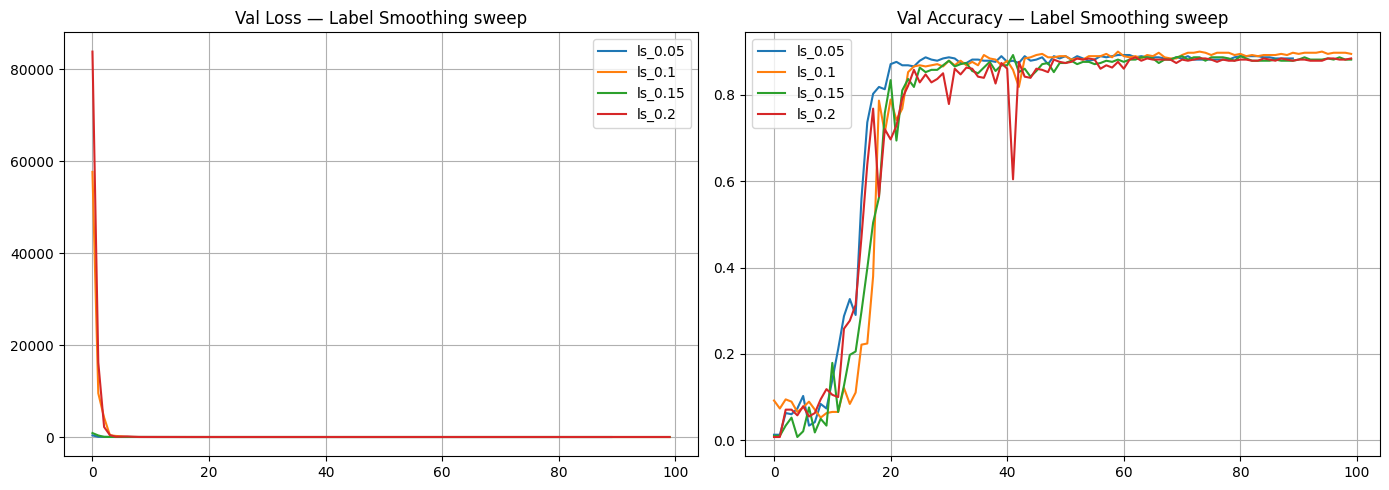

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    axes[0].plot(r['hist']['val_loss'],     label=name)
    axes[1].plot(r['hist']['val_accuracy'], label=name)
axes[0].set_title('Val Loss — Label Smoothing sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy — Label Smoothing sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_ls_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Evaluation (best config)

In [9]:
print(f"Retraining with best label smoothing = {BEST_LS}")

model = build_model()
model.compile(
    optimizer=optimizers.AdamW(learning_rate=LR, weight_decay=WEIGHT_DECAY),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=BEST_LS),
    metrics=['accuracy']
)
log_dir = os.path.join(LOG_DIR, MODEL_NAME, f'best_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=100,
    batch_size=BATCH_SIZE,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=1),
        callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),
    ],
    verbose=1
)

Retraining with best label smoothing = 0.1
Epoch 1/100


I0000 00:00:1776170842.418357   73756 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_346176__.242


23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.0809 - loss: 4.2699

I0000 00:00:1776170850.065715   73756 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_346176__.242


24/24 ━━━━━━━━━━━━━━━━━━━━ 22s 374ms/step - accuracy: 0.1332 - loss: 3.7972 - val_accuracy: 0.0106 - val_loss: 170.9439 - learning_rate: 0.0010
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.3107 - loss: 2.8260 - val_accuracy: 0.0106 - val_loss: 38.4834 - learning_rate: 0.0010
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 136ms/step - accuracy: 0.4360 - loss: 2.3697 - val_accuracy: 0.0026 - val_loss: 14.5146 - learning_rate: 0.0010
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.5442 - loss: 2.0649 - val_accuracy: 0.0106 - val_loss: 30.0577 - learning_rate: 0.0010
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.6253 - loss: 1.8561 - val_accuracy: 0.0079 - val_loss: 12.8467 - learning_rate: 0.0010
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.6873 - loss: 1.6515 - val_accuracy: 0.0132 - val_loss: 20.5003 - learning_rate: 0.0010
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.7315 - loss: 1.5309

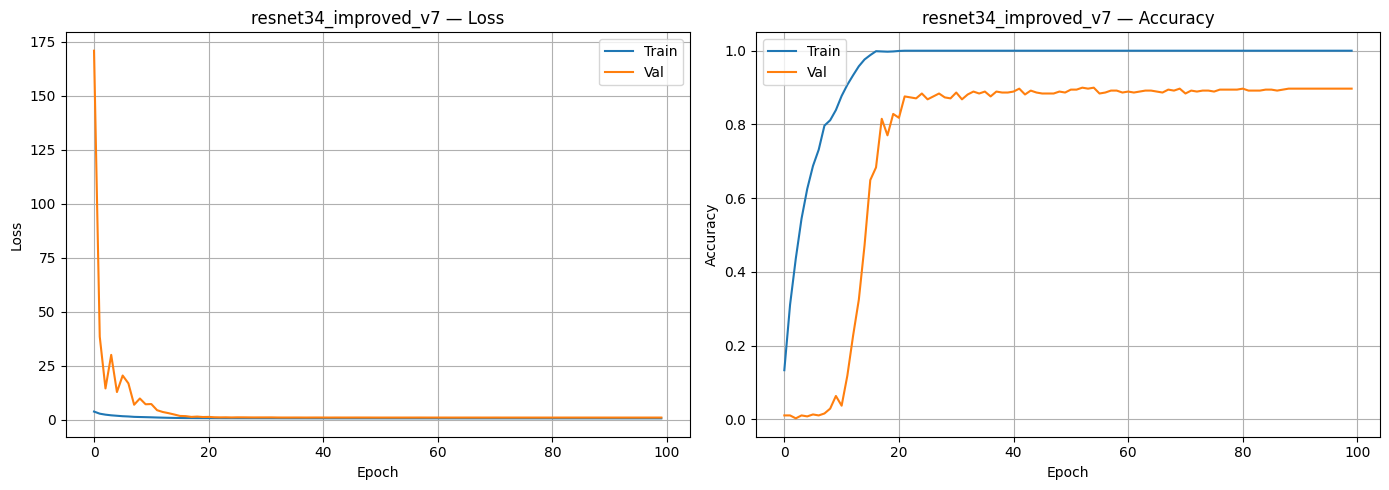

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title(f'{MODEL_NAME} — Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{MODEL_NAME} — Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
train_loss, train_acc = model.evaluate(X_train, y_train_oh, verbose=0)
val_loss, val_acc     = model.evaluate(X_val, y_val_oh, verbose=0)

print(f"{MODEL_NAME} (LR={LR}, label_smoothing={BEST_LS}):")
print(f"  Train — Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   — Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

resnet34_improved_v7 (LR=0.001, label_smoothing=0.1):
  Train — Loss: 0.6538, Acc: 1.0000
  Val   — Loss: 1.0227, Acc: 0.8945


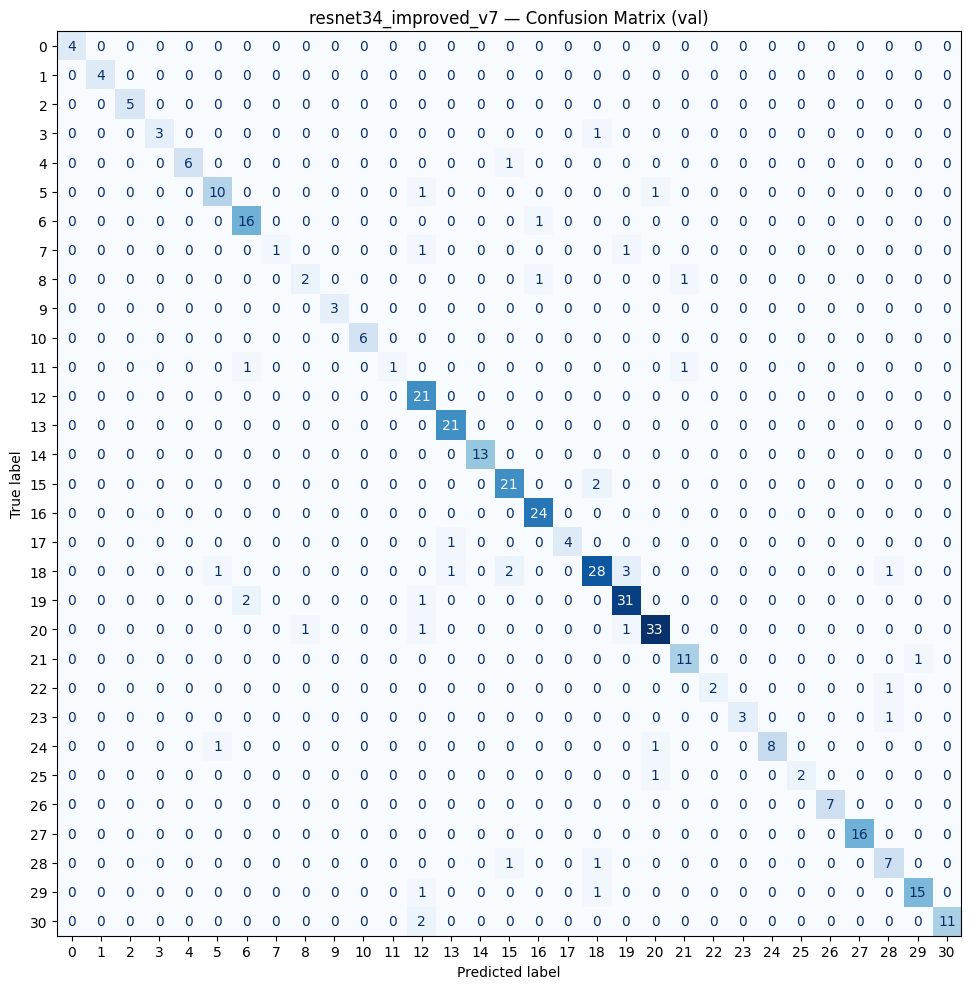

In [12]:
y_val_pred = model.predict(X_val, batch_size=BATCH_SIZE, verbose=0).argmax(axis=1)

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{MODEL_NAME} — Confusion Matrix (val)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Kaggle submission

In [13]:
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])
y_all_oh = tf.keras.utils.to_categorical(y_all, NUM_CLASSES)

print(f"Retraining on full dataset ({len(X_all)} images) for {BEST_EPOCH} epochs")
print(f"Label smoothing = {BEST_LS}")

final_model = build_model()
final_model.compile(
    optimizer=optimizers.AdamW(learning_rate=LR, weight_decay=WEIGHT_DECAY),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=BEST_LS),
    metrics=['accuracy']
)

final_log = os.path.join(LOG_DIR, MODEL_NAME, f'final_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
final_model.fit(
    X_all, y_all_oh,
    epochs=BEST_EPOCH,
    batch_size=BATCH_SIZE,
    callbacks=[callbacks.TensorBoard(log_dir=final_log)],
    verbose=1
)
print(f"Final train acc: {final_model.evaluate(X_all, y_all_oh, verbose=0)[1]:.4f}")

Retraining on full dataset (1895 images) for 93 epochs
Label smoothing = 0.1
Epoch 1/93


I0000 00:00:1776171160.694032   73754 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2903389__.242


29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.1129 - loss: 4.1889

I0000 00:00:1776171168.665232   73754 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2903389__.242
I0000 00:00:1776171170.658322  116039 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_6', 16 bytes spill stores, 16 bytes spill loads



30/30 ━━━━━━━━━━━━━━━━━━━━ 24s 408ms/step - accuracy: 0.1673 - loss: 3.6143
Epoch 2/93
30/30 ━━━━━━━━━━━━━━━━━━━━ -1s -24209us/step - accuracy: 0.3541 - loss: 2.7312
Epoch 3/93
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.4422 - loss: 2.4262
Epoch 4/93
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.5367 - loss: 2.1647
Epoch 5/93
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.6190 - loss: 1.8846
Epoch 6/93
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.6823 - loss: 1.7109
Epoch 7/93
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.7456 - loss: 1.5503
Epoch 8/93
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.7879 - loss: 1.4163
Epoch 9/93
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.8174 - loss: 1.2938
Epoch 10/93
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.8617 - loss: 1.1854
Epoch 11/93
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.8860 - loss: 1.1182
Epoch 12/93
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.8

I0000 00:00:1776171382.378433  120698 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_2', 16 bytes spill stores, 16 bytes spill loads



Final train acc: 1.0000


In [14]:
embedding_model = keras.Model(
    inputs=final_model.input,
    outputs=final_model.layers[-2].output,
    name=f'{MODEL_NAME}_embedding'
)

test_embeddings = embedding_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embedding shape: {test_embeddings_norm.shape}")

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx   = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

similarities = np.clip(
    np.sum(test_embeddings_norm[query_idx] * test_embeddings_norm[gallery_idx], axis=1),
    0, 1
)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, f'submission_{MODEL_NAME}.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")
display(submission.head())

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 425ms/step
Embedding shape: (371, 512)
Saved: /home/franck/kaggle_jaguar_classification/submissions/submission_resnet34_improved_v7.csv


,row_id,similarity
0,0,0.832703
1,1,0.679145
2,2,0.677404
3,3,0.799950
4,4,0.845802


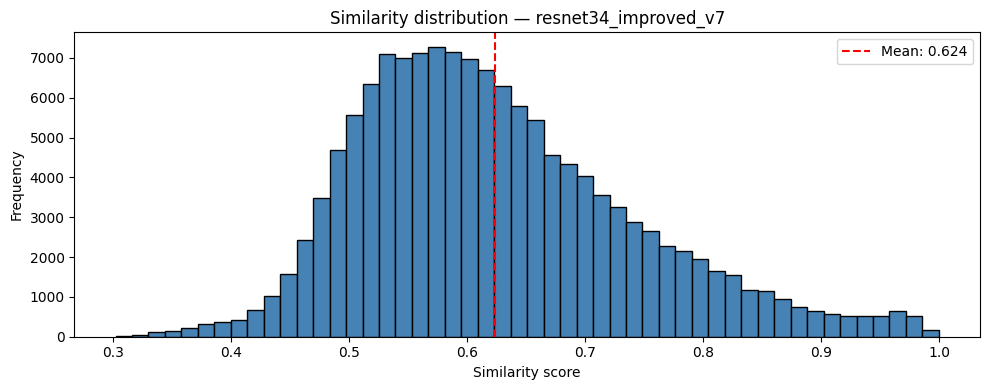

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.axvline(similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.set_xlabel('Similarity score'); ax.set_ylabel('Frequency')
ax.set_title(f'Similarity distribution — {MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary

In [16]:
print(f"""
ResNet-34 improved v7 (label smoothing tuning):
  Best label smoothing: {BEST_LS}
  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}
  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}
  LR: {LR}, Best Epoch: {BEST_EPOCH}
  Embedding dim: {test_embeddings.shape[1]}

vs 06_6 (label_smoothing=0.1):
  Val Acc: 90.77%, Kaggle: 0.636 / 0.629

Submission -> {submission_path}
""")


ResNet-34 improved v7 (label smoothing tuning):
  Best label smoothing: 0.1
  Train - Loss: 0.6538, Acc: 1.0000
  Val   - Loss: 1.0227, Acc: 0.8945
  LR: 0.001, Best Epoch: 93
  Embedding dim: 512

vs 06_6 (label_smoothing=0.1):
  Val Acc: 90.77%, Kaggle: 0.636 / 0.629

Submission -> /home/franck/kaggle_jaguar_classification/submissions/submission_resnet34_improved_v7.csv



## 7. Observations & Verdict

### Results — Label Smoothing Sweep

| α (smoothing) | Val Accuracy | Best Epoch | Observation |
|---------------|-------------|------------|-------------|
| 0.05 | 88.65 % | 70 | Conservateur — quasi identique à no-smoothing (06_2) |
| **0.10** | **89.71 %** | 93 | Meilleur α — confirme 06_6 |
| 0.15 | 87.86 % | 90 | Trop agressif — perd de l'information discriminative |
| 0.20 | 88.13 % | 86 | Trop agressif — le modèle ne peut plus être assez confiant |

### Eval finale (best α = 0.1)

| Métrique | Train | Val |
|----------|-------|-----|
| Accuracy | 100.00 % | 89.45 % |
| Loss | 0.6538 | 1.0227 |
| Best epoch | 93 / 100 | |
| Retrain final acc | 100.00 % | |
| Kaggle public | **0.650** | |
| Kaggle private | **0.610** | |

### Analysis

**α = 0.1 est confirmé comme la valeur optimale.** Le sweep montre une courbe en cloche :

- **α = 0.05** (88.65 %) : trop conservateur. La cible (0.95 / 0.0017) est presque identique à un one-hot pur → le modèle pousse encore les logits très haut → même comportement que sans label smoothing. Retour au plateau de 88.65 % de 06_2.
- **α = 0.10** (89.71 %) : sweet spot. La cible (0.90 / 0.003) empêche l'explosion des logits tout en gardant assez de signal discriminatif. Le modèle sait toujours "quelle classe" mais sans sur-confiance.
- **α = 0.15** (87.86 %) : trop agressif. La cible (0.85 / 0.005) commence à "flouter" les frontières entre classes. Le modèle n'a plus assez de signal pour distinguer les jaguars similaires.
- **α = 0.20** (88.13 %) : encore plus agressif. La cible (0.80 / 0.0067) dilue trop l'information → le modèle apprend des features trop génériques.

**Convergence** : plus α est grand, plus le modèle converge longtemps (70 → 93 → 90 → 86 epochs). Le label smoothing adoucit le paysage de la loss → la convergence est plus progressive. Exception : α=0.15 et 0.2 convergent un peu moins longtemps car l'EarlyStopping détecte que le modèle n'arrive plus à progresser.

**Kaggle = 0.650 / 0.610** : nouveau record public (+2 % vs 06_6). Le score private baisse (0.610 vs 0.629), ce qui peut indiquer de la variance entre runs plutôt qu'une réelle amélioration. La même config α=0.1 donne des scores proches entre 06_6 et 06_7, confirmant la stabilité du résultat.

**Val accuracy 06_7 (89.45 %) vs 06_6 (90.77 %)** : la variance entre runs est significative (~1-2 pts). Les deux notebooks utilisent la même config (α=0.1, LR=1e-3), la différence vient uniquement de l'initialisation aléatoire et de la stochasticité de l'entraînement.

### Verdict

- [x] Improvable -> Le label smoothing à α=0.1 est optimal, mais il reste d'autres axes à explorer : dropout tuning, weight decay tuning, batch size. Ces leviers sont indépendants du label smoothing et pourraient apporter des gains supplémentaires.

### Interpretation

_Le label smoothing suit une courbe en cloche avec un optimum clair à α=0.1. Ce n'est pas un hyperparamètre qu'il faut tuner finement (0.05 et 0.15 sont déjà significativement moins bons). On peut fixer α=0.1 et passer aux autres axes d'optimisation. La variance entre runs (~1-2 pts val, ~2-3 % Kaggle) est le facteur limitant — les prochaines expériences devront être interprétées avec cette marge en tête._